# Replica exchange

Near its transition temperature, a single trajectory crosses between folded
and unfolded only rarely, so its averages take a very long run to settle.
Replica exchange runs several copies of the system side by side, each at its
own temperature. After every cycle of Monte Carlo steps it tries to swap the
copies at neighbouring temperatures, so each copy wanders up and down the
ladder, unfolding when it is hot and refolding when it is cold, and every
temperature is sampled much faster.

In pyMCPU's output, a **slot** is one fixed temperature (and umbrella
window), and a **walker** is one copy of the protein as it moves between
slots.

This tutorial runs a small replica exchange on chignolin in this process,
then reads its output: the swap rates, a melting curve, and the path of each
walker. It takes about 30 seconds and, like the first tutorial, needs
matplotlib. [Running replica exchange](../running_remd.md) covers the
configuration and MPI in more detail.

## 1. Write a config

Replica exchange is set up from a config, the same file you would pass to
`mcpu run`. This one has eight temperatures. They bracket what the first
tutorial showed, folded at 0.5 and unfolded at 0.8, and are closer together
around the transition. For your own protein, run short single trajectories
first to find where it unfolds.

There is one umbrella window. `k_bias: 0` switches its umbrella off; without
that line, the window would pull every walker toward unfolded structures,
with the default strength of 1.0.

In [1]:
import yaml

from pymcpu.runners import default_example_pdb

config = {
    "pdb": str(default_example_pdb()),
    "temperatures": [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 1.0],
    "k_bias": 0,               # required: switches the umbrella off
    "contact_cutoff": 8.0,     # native contacts as in the first tutorial
    "num_cycles": 300,         # each cycle: MC steps, then one round of swaps
    "mc_replica_steps": 1000,  # MC steps per replica per cycle
    "seed": 7,
    "output_prefix": "remd_output/run1",
    "exchange_log": "all",     # record every swap attempt
    "state_log_interval": 1,   # record every slot's Q and energy each cycle
    "checkpointing": {"checkpoint_dir": "remd_output/checkpoints"},
}
with open("remd.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

## 2. Run it

From a terminal, `mcpu run remd.yaml` runs this config. Here we call the same
function from Python. All eight walkers run in this one process, one after
another; to spread them over MPI processes, see [Running replica
exchange](../running_remd.md).

In [2]:
from pymcpu.config import load_config_auto
from pymcpu.runners import run_from_config

summary = run_from_config(load_config_auto("remd.yaml"), verbose=False)
print(f"finished in {summary.elapsed_s:.0f} s")

finished in 23 s


## 3. What it wrote

In [3]:
import os

print("\n".join(sorted(os.listdir("remd_output"))))

checkpoints
run1_exchange.csv
run1_rex_stats.json
run1_state.csv
run1_t00_q00.xtc
run1_t00_q00_data.csv
run1_t01_q00.xtc
run1_t01_q00_data.csv
run1_t02_q00.xtc
run1_t02_q00_data.csv
run1_t03_q00.xtc
run1_t03_q00_data.csv
run1_t04_q00.xtc
run1_t04_q00_data.csv
run1_t05_q00.xtc
run1_t05_q00_data.csv
run1_t06_q00.xtc
run1_t06_q00_data.csv
run1_t07_q00.xtc
run1_t07_q00_data.csv


Every file name starts with `run1`, the last part of `output_prefix`. The
`run1_tXX_qYY` files belong to slots: `t00` to `t07` are the temperatures
from the coldest, and `q00` is the only window. So `run1_t00_q00.xtc` is the
trajectory at T = 0.5, made of whichever walkers were there; the `walker_id`
column of `run1_t00_q00_data.csv` says which. In `run1_state.csv` and
`run1_exchange.csv`, the `replica`, `replica_i` and `replica_j` columns are
slots too, and walkers are `walker_id`. The checkpoints let a stopped run
continue ([Checkpointing and resume](../checkpointing.md)).

A slot's trajectory holds the input's heavy atoms in their original order, so
read it with the same topology as in the first tutorial:

In [4]:
import mdtraj as md

structure = md.load(str(default_example_pdb()))
heavy = structure.atom_slice(structure.topology.select("not element H"))
cold = md.load("remd_output/run1_t00_q00.xtc", top=heavy.topology)
print(cold)

<mdtraj.Trajectory with 301 frames, 77 atoms, 10 residues, without unitcells>


## 4. Swap rates

`run1_rex_stats.json` has the overall rate of temperature swaps:

In [5]:
import json

with open("remd_output/run1_rex_stats.json") as f:
    print(json.load(f)["temperature"])

{'attempts': 2100, 'accepted': 1417, 'rate': 0.6747619047619048}


`run1_exchange.csv` has every attempt, so it gives the rate of each
neighbouring pair:

In [6]:
import pandas as pd

swaps = pd.read_csv("remd_output/run1_exchange.csv")
per_pair = swaps.groupby(["temperature_i", "temperature_j"])["accepted"].mean()
print(per_pair.round(2).to_string())

temperature_i  temperature_j
0.50           0.60             0.55
0.60           0.65             0.74
0.65           0.70             0.58
0.70           0.75             0.71
0.75           0.80             0.76
0.80           0.90             0.66
0.90           1.00             0.72


Every neighbouring pair swaps more than half the time. A pair that rarely
swaps splits the ladder into parts that do not mix; add a temperature
between them. Rates as high as these mean the same range could be covered
with fewer temperatures.

## 5. Melting curve

`run1_state.csv` records, every cycle, each slot's temperature, its N (the
number of native contacts formed) and Q, its energy, and the walker in it.
Average Q at each temperature, leaving out the first 50 cycles while the
walkers spread out from the native structure:

temperature
0.50    0.94
0.60    0.86
0.65    0.74
0.70    0.40
0.75    0.25
0.80    0.16
0.90    0.09
1.00    0.08


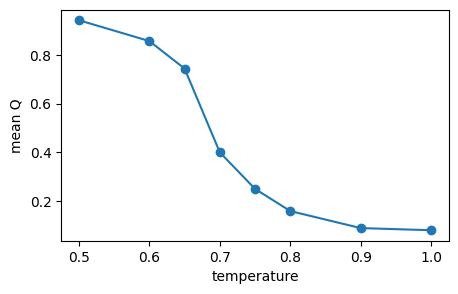

In [7]:
import matplotlib.pyplot as plt

state = pd.read_csv("remd_output/run1_state.csv")
melting = state[state["cycle"] > 50].groupby("temperature")["Q"].mean()
print(melting.round(2).to_string())

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(melting.index, melting.values, "o-")
ax.set_xlabel("temperature")
ax.set_ylabel("mean Q")
plt.show()

Q falls from 0.94 at T = 0.5 to 0.08 at T = 1.0, most steeply between 0.65
and 0.75: in this run, chignolin melts at about 0.7. Three hundred cycles
give only a rough curve. With another seed the midpoint moves by as much as
0.1, and longer runs settle it at about 0.65 to 0.7. A production run uses
many more cycles, and checks that the curve no longer changes as the run gets
longer.

## 6. How the walkers move

Replica exchange only helps if the walkers travel along the ladder. Follow
three of them:

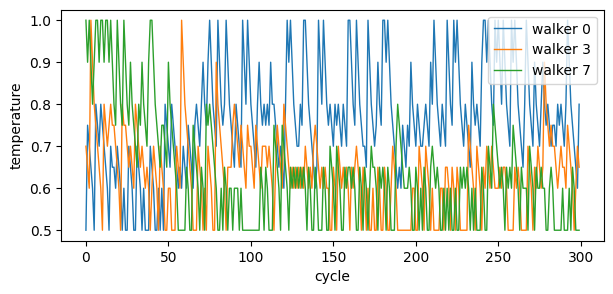

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
for walker in (0, 3, 7):
    path = state[state["walker_id"] == walker].sort_values("cycle")
    ax.plot(path["cycle"], path["temperature"], lw=1, label=f"walker {walker}")
ax.set_xlabel("cycle")
ax.set_ylabel("temperature")
ax.legend(loc="upper right")
plt.show()

Each of these walkers visits every temperature, from the coldest to the
hottest. That is how structures that unfold at high temperature reach the low
ones, and the reverse. A walker that stayed near its starting temperature
would mean the swaps are not doing their job.

## 7. Umbrella windows

To also sample at different numbers of native contacts, add umbrella windows
to the config:

```yaml
q_targets: [0.2, 0.4, 0.6, 0.8]  # umbrella centres, as a fraction of the native contacts
k_bias: 0.5                      # strength of the harmonic umbrella on N
```

The grid is then temperatures × windows, here 8 × 4 = 32 slots and as many
walkers, and neighbouring windows swap too. Combining the windows into one free-energy
profile needs reweighting, for example with MBAR; setting `hdf5:` in the
config writes the samples it needs (see [Analysis](../api/analysis.rst)).

## Where to go next

- **MPI and Slurm:** [Running replica exchange](../running_remd.md).
- **Long runs and restarts:** [Checkpointing and resume](../checkpointing.md).
- **Free energies:** [Analysis](../api/analysis.rst).